In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metrics = pd.read_csv("./experiment_results.csv")
features = pd.read_csv("./cluster_features.csv")
print(f"loaded {len(metrics)} rows, {metrics['unique_id'].nunique()} series")
metrics.head()

loaded 1200 rows, 150 series


,unique_id,model,transformation,smape,mase,cluster
0,M10000,Naive,identity,18.994155,0.499230,0
1,M10000,SeasonalNaive,identity,12.923257,0.319410,0
2,M10000,AutoTheta,identity,18.133940,0.466944,0
3,M10000,AutoETS,identity,18.994201,0.499231,0
4,M10756,Naive,identity,7.182653,3.607238,0


### Сравнение трансформаций для catboost

In [4]:
cb = metrics[metrics["model"] == "CatBoost"].copy()
summary = cb.groupby("transformation")[["smape", "mase"]].agg(["mean", "median", "std"]).round(3)
print(summary.to_string())

                 smape                  mase              
                  mean median     std   mean median    std
transformation                                            
boxcox          15.795  7.967  17.806  1.147  0.895  0.865
differencing    14.855  6.520  17.609  1.030  0.816  0.750
identity        15.719  7.998  18.084  1.147  0.855  0.903
log1p           15.817  8.009  17.608  1.180  0.854  0.871


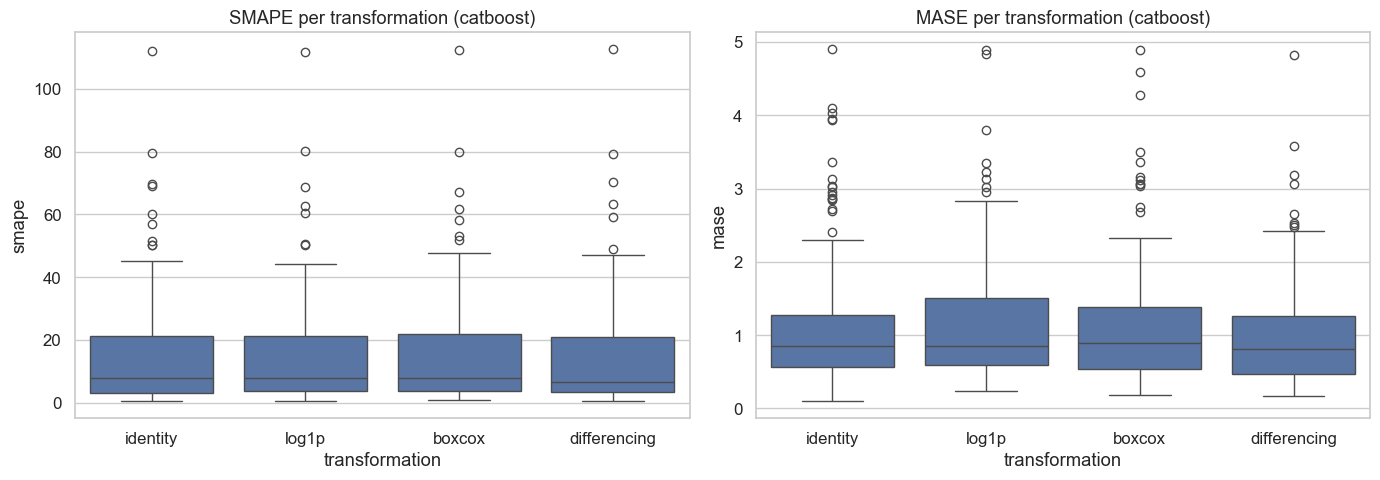

In [26]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["smape", "mase"]):
    sns.boxplot(data=cb, x="transformation", y=metric, ax=ax, order=["identity", "log1p", "boxcox", "differencing"])
    ax.set_title(f"{metric.upper()} per transformation (catboost)")
plt.tight_layout()
plt.savefig("./catboost_trans_boxplot.png", dpi=150)
plt.show()

### бейзлайны vs катбуст с лучшей трансформацией

In [10]:
overall = metrics.groupby(["model", "transformation"])[["smape", "mase"]].mean().round(3)
print(overall.sort_values("smape").to_string())

                               smape   mase
model         transformation               
AutoTheta     identity        14.145  0.939
AutoETS       identity        14.616  0.911
CatBoost      differencing    14.855  1.030
              identity        15.719  1.147
              boxcox          15.795  1.147
              log1p           15.817  1.180
Naive         identity        17.056  1.182
SeasonalNaive identity        17.545  1.193


### Профили кластеров

In [13]:
feat_cols = [c for c in features.columns if c not in ("unique_id", "cluster")]
cluster_profile = features.groupby("cluster")[feat_cols].mean().round(3)
print(cluster_profile.to_string())
print()
print("Cluster sizes:")
print(features["cluster"].value_counts().sort_index())

             mean       std     cv  trend_strength  seasonality_strength   acf1  acf_seasonal  diff_acf1  skewness  kurtosis   length
cluster                                                                                                                              
0        4053.767  1080.525  0.273           0.933                 0.322  0.937         0.692      0.033     0.186    -0.586  236.216
1        3997.311  1214.368  0.334           0.399                 0.196  0.447         0.192     -0.413     0.831     3.534  108.147

Cluster sizes:
cluster
0    116
1     34
Name: count, dtype: int64


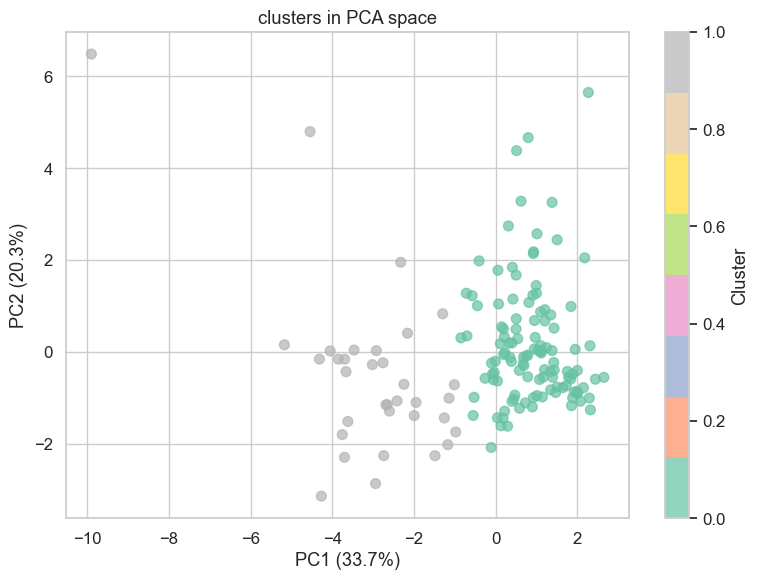

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(features[feat_cols])
pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X2[:, 0], X2[:, 1], c=features["cluster"], cmap="Set2", alpha=0.7, s=50)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("clusters in PCA space")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("./pca_clusters.png", dpi=150)
plt.show()

### Влияние трансформации по кластерам

In [18]:
pivot_smape = (
    cb.groupby(["cluster", "transformation"])["smape"]
    .mean()
    .unstack("transformation")
    .round(2)
)
pivot_mase = (
    cb.groupby(["cluster", "transformation"])["mase"]
    .mean()
    .unstack("transformation")
    .round(2)
)
print(" mean sMAPE by cluster & transformation ")
print(pivot_smape.to_string())
print()
print(" mean MASE by cluster & transformation ")
print(pivot_mase.to_string())

 mean sMAPE by cluster & transformation 
transformation  boxcox  differencing  identity  log1p
cluster                                              
0                12.28         11.09     12.20  12.38
1                27.78         27.70     27.72  27.55

 mean MASE by cluster & transformation 
transformation  boxcox  differencing  identity  log1p
cluster                                              
0                 1.18          1.02      1.17   1.21
1                 1.04          1.06      1.08   1.08


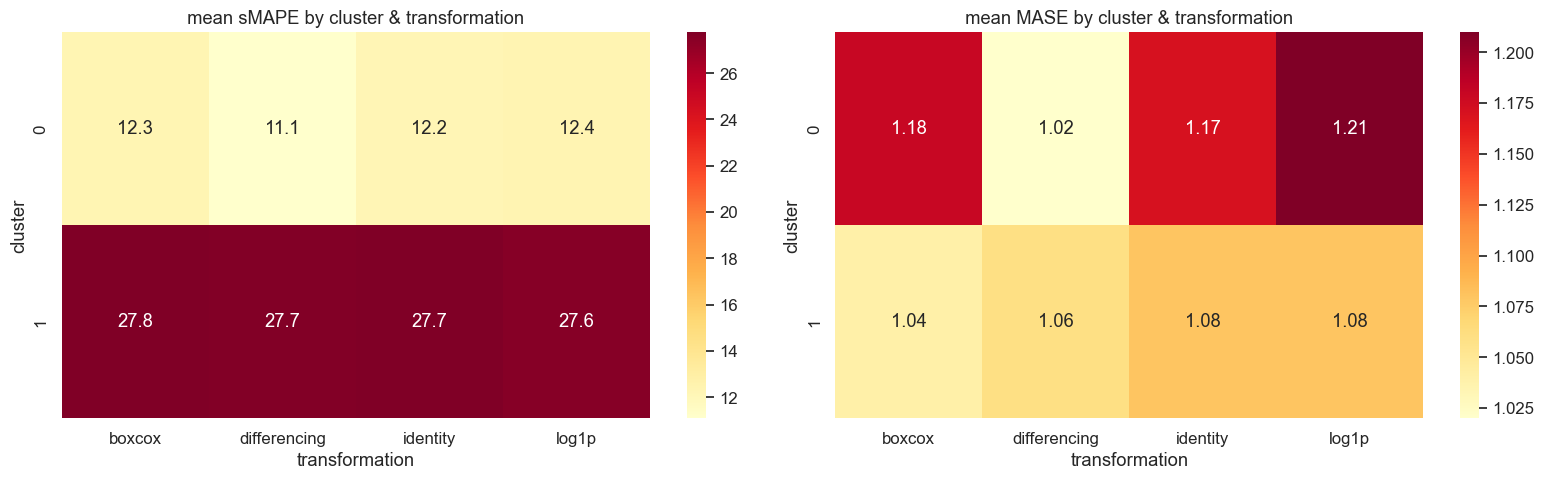

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_smape, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0])
axes[0].set_title(" mean sMAPE by cluster & transformation ")
sns.heatmap(pivot_mase, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title(" mean MASE by cluster & transformation ")
plt.tight_layout()
plt.savefig("./heatmap_cluster_transform.png", dpi=150)
plt.show()

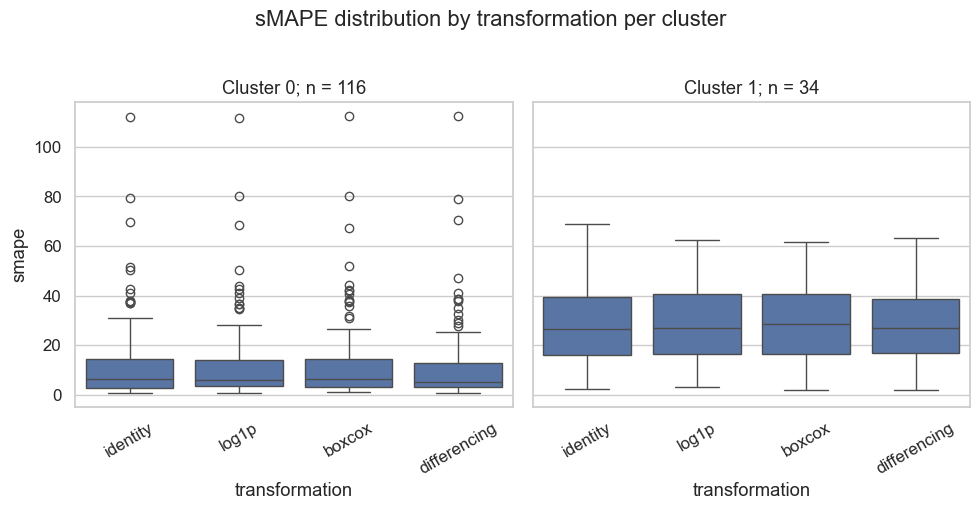

In [22]:
n_clusters = cb["cluster"].nunique()
fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5), sharey=True)
if n_clusters == 1:
    axes = [axes]
for cl, ax in enumerate(axes):
    sub = cb[cb["cluster"] == cl]
    sns.boxplot(data=sub, x="transformation", y="smape", ax=ax, order=["identity", "log1p", "boxcox", "differencing"])
    ax.set_title(f"Cluster {cl}; n = {sub['unique_id'].nunique()}")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("sMAPE distribution by transformation per cluster", y=1.02)
plt.tight_layout()
plt.savefig("./boxplot_per_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

### Примеры рядов из каждого кластера

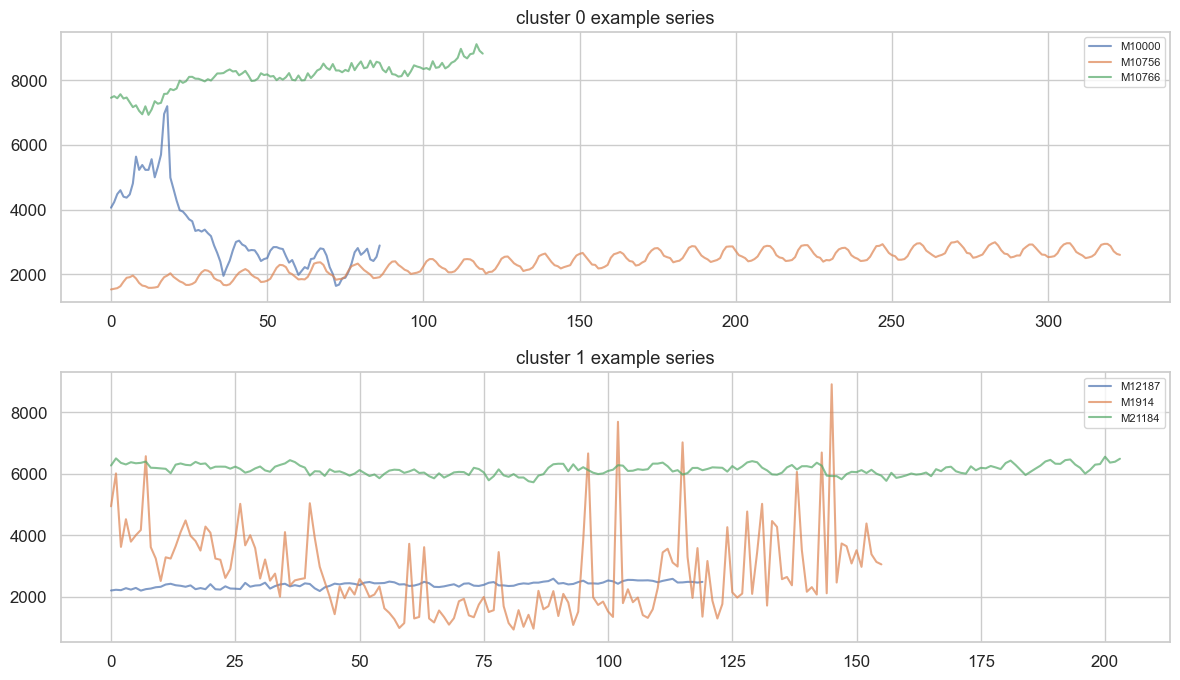

In [25]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.data import load_ds, train_test_split, series2dict

df = load_ds()
train_df, test_df = train_test_split(df)
train_dict = series2dict(train_df)
test_dict = series2dict(test_df)

n_clusters = features["cluster"].nunique()
fig, axes = plt.subplots(n_clusters, 1, figsize=(12, 3.5 * n_clusters))
if n_clusters == 1:
    axes = [axes]
for cl, ax in enumerate(axes):
    uids = features[features["cluster"] == cl]["unique_id"].values[:3]
    for uid in uids:
        if uid in train_dict:
            full = np.concatenate([train_dict[uid], test_dict[uid]])
            ax.plot(full, alpha=0.7, label=uid)
    ax.set_title(f"cluster {cl} example series")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("./example_series.png", dpi=150)
plt.show()